Begin with an image:

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

For implementation we begin with classical gradient flow on $R$. 
We have 
$$
        \text{I}(\rho) = \rho_\text{I}(x,z) = \int_0^1\rho(x,y,z)dy \\
        \text{II}(\rho) = \rho_\text{II}(y,z) = \int_0^1 \rho(x,y,z)dx
$$

$$
        \mathcal{E} = \frac{1}{2}||\text{I}(R)-\rho_\text{I}||_2^2 + \frac{1}{2}||\text{II}(R)-\rho_\text{II}||_2^2 + \text{regularisation}
$$

$$
        R = \arg \min \mathcal{E}
$$

Suppose $R = R[i,j,k]$ is a 3D array.

In [12]:
# image parameters
g = 1
t = 5

# image paths
xz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_xz.png")

yz_path = (f"../../data/synthetic/images/gen_{g:02d}/plant_gen{g:02d}_t{t:02d}_yz.png")

# load images
img_xz = cv2.imread(xz_path, cv2.IMREAD_GRAYSCALE)
img_yz = cv2.imread(yz_path, cv2.IMREAD_GRAYSCALE)

if img_xz is None:
    raise FileNotFoundError(xz_path)

if img_yz is None:
    raise FileNotFoundError(yz_path)

# convert to [0,1]
rho_xz = (img_xz > 0).astype(np.float32)
rho_yz = (img_yz > 0).astype(np.float32)

# optional denoising / uncertainty model
# rho_xz = cv2.GaussianBlur(rho_xz, (0, 0), sigmaX=2)
# rho_yz = cv2.GaussianBlur(rho_yz, (0, 0), sigmaX=2)

# construct R0
# note rho_xz has shape (H, W) and rho_yz has shape (H, D) so first entry is z
R0 = rho_xz[:, :, None] * rho_yz[:, None, :]
R0 = np.transpose(R0, (1, 2, 0))  

print("rho_xz shape:", rho_xz.shape)
print("rho_yz shape:", rho_yz.shape)
print("R0 shape:", R0.shape)
print("R0 mass:", R0.sum())

rho_xz shape: (512, 512)
rho_yz shape: (512, 512)
R0 shape: (512, 512, 512)
R0 mass: 2083.0


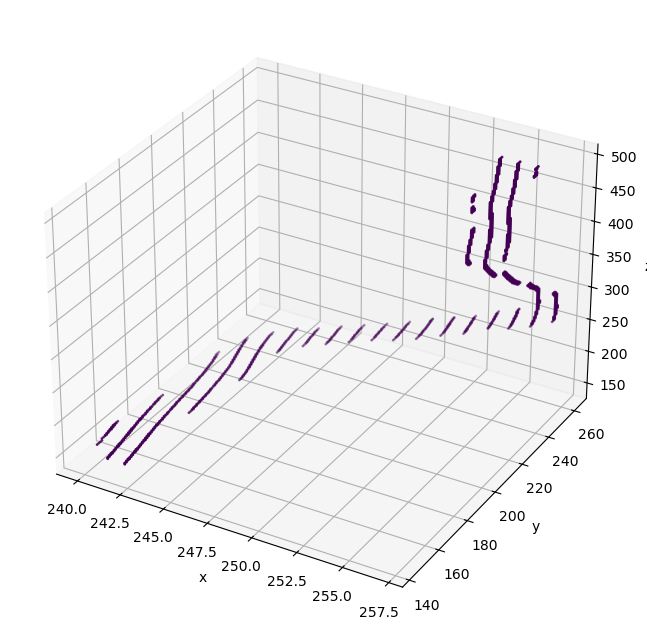

In [13]:
threshold = 0

x, y, z = np.where(R0 > threshold)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, s=1, c=R0[x,y,z], cmap='viridis')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()